In [1]:
import numpy as np

In [3]:
import pandas as pd

In [7]:
import matplotlib.pyplot as plt

In [9]:
%matplotlib inline

In [13]:
from scipy.stats import norm

In [15]:
import yfinance as yf

In [27]:
ticker='GE'
data=pd.DataFrame()
data[ticker]=yf.Ticker(ticker).history(start='2007-1-1', end='2017-3-21')['Close']
data

,GE
Date,
2007-01-03 00:00:00-05:00,115.241684
2007-01-04 00:00:00-05:00,114.573997
2007-01-05 00:00:00-05:00,113.997322
2007-01-08 00:00:00-05:00,113.966972
2007-01-09 00:00:00-05:00,113.966972
...,...
2017-03-14 00:00:00-04:00,129.849777
2017-03-15 00:00:00-04:00,130.816833
2017-03-16 00:00:00-04:00,130.772873


In [31]:
logret=np.log(1+data.pct_change())
logret

,GE
Date,
2007-01-03 00:00:00-05:00,NaN
2007-01-04 00:00:00-05:00,-0.005811
2007-01-05 00:00:00-05:00,-0.005046
2007-01-08 00:00:00-05:00,-0.000266
2007-01-09 00:00:00-05:00,0.000000
...,...
2017-03-14 00:00:00-04:00,-0.010775
2017-03-15 00:00:00-04:00,0.007420
2017-03-16 00:00:00-04:00,-0.000336


In [33]:
r=0.025

In [37]:
stdev=logret.std()*250**0.5
stdev

GE    0.310896
dtype: float64

In [41]:
type(stdev)

pandas.Series

In [57]:
stdev=np.array(stdev)
stdev

array([0.31089636])

In [71]:
t=1
t_intervals=250
delta_t=(t/t_intervals)

iterations=1000

In [80]:
z=np.random.standard_normal((t_intervals+1,iterations))
S=np.zeros_like(z)
S0=data.iloc[-1]
S[0]=S0

S

array([[130.72888184, 130.72888184, 130.72888184, ..., 130.72888184,
        130.72888184, 130.72888184],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

In [86]:
for t in range(1,t_intervals+1):
    S[t]=S[t-1]*(np.exp((r-((stdev**2)/2))*delta_t)+(stdev*(delta_t**0.5)*z[t]))

In [88]:
S

array([[130.72888184, 130.72888184, 130.72888184, ..., 130.72888184,
        130.72888184, 130.72888184],
       [128.30764376, 130.5552534 , 132.14372442, ..., 130.66182723,
        128.05872402, 129.71689045],
       [125.88962087, 130.86957819, 135.18082158, ..., 126.23471975,
        123.98857645, 131.59705975],
       ...,
       [131.25437233, 109.08363887,  69.9938932 , ..., 135.69148689,
        104.02406283, 157.1312986 ],
       [134.9058401 , 110.18375906,  71.08291684, ..., 132.89432234,
        106.53594723, 157.61649166],
       [134.45913071, 111.2877242 ,  71.21532904, ..., 137.34535122,
        104.2000734 , 155.84060988]])

In [90]:
S.shape

(251, 1000)

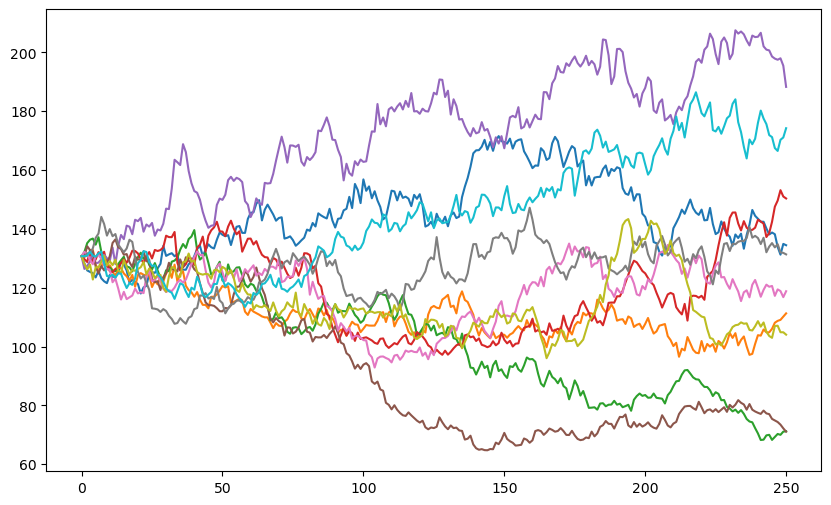

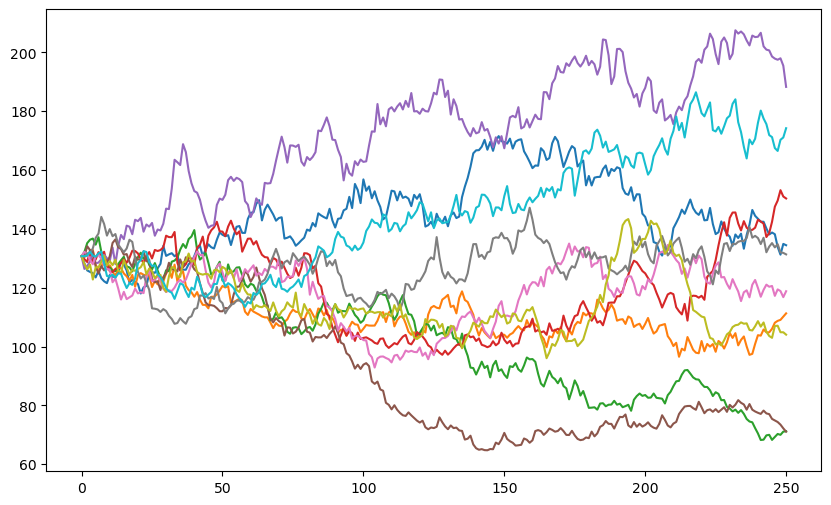

In [94]:
plt.figure(figsize=(10,6))
plt.plot(S[:,:10])
plt.show()

In [110]:
K=110

In [112]:
payoff=np.maximum(S[-1]-K,0)
payoff

array([2.44591307e+01, 1.28772420e+00, 0.00000000e+00, 4.03532587e+01,
       7.82885554e+01, 0.00000000e+00, 8.81871061e+00, 2.13418405e+01,
       0.00000000e+00, 6.42422762e+01, 0.00000000e+00, 0.00000000e+00,
       2.27451209e+01, 1.28022506e+02, 0.00000000e+00, 1.35789011e+01,
       4.24712624e+01, 4.69675855e+01, 0.00000000e+00, 6.11304153e+01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.35058499e+01,
       0.00000000e+00, 5.40622808e+01, 5.59417356e+01, 0.00000000e+00,
       7.05456172e+01, 1.09940833e+01, 2.37354972e+01, 3.43656778e+01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.39547022e+01,
       0.00000000e+00, 0.00000000e+00, 1.32476643e+01, 0.00000000e+00,
       2.92518799e-01, 5.35889220e+01, 0.00000000e+00, 9.49391698e+00,
       2.55172876e+01, 1.58156923e+00, 0.00000000e+00, 1.48490107e+01,
       0.00000000e+00, 9.01812438e+00, 4.51938871e+01, 5.49144709e+01,
       0.00000000e+00, 3.87452991e+00, 0.00000000e+00, 0.00000000e+00,
      

In [114]:
payoff.shape

(1000,)

In [118]:
call=(np.exp(-r*t)*np.sum(payoff))/iterations
call

0.051724894354406796